# Investigate why ICON pp models are so bad

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import json

import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
# import polars as pl
# import seaborn as sns

# import wandb
# from genpp.plots import RESULTS_DIR

from genpp.eval.icon import best_models
from pathlib import Path

In [3]:
fm_uvit_noise = [model for model in best_models.fm if model.tag == "ind_uvit"][0]
fm_uvit_noise.model_dir
gt_file = fm_uvit_noise.model_dir / "test_ground_truth.pt"
predictions = fm_uvit_noise.model_dir / "test_predictions.pt"

In [4]:
baseline_scores = Path(
    "/hpc/uhome/extmfeik/GenPP/src/genpp/data/icon/data/scores/raw_ensemble/merged.csv"
)
df = pl.read_csv(baseline_scores)
df

init_time,valid_date,leadtime_hours,n_members,energy_score,energy_score_T_2M,energy_score_VMAX_10M,crps_mean,crps_T_2M,crps_VMAX_10M
i64,i64,i64,i64,f64,f64,f64,f64,f64,f64
2019011500,20190116,24,40,504.941101,241.078461,444.077087,1.011081,0.729993,1.292168
2019011500,20190117,48,40,537.798523,280.322235,459.442627,1.072919,0.794275,1.351564
2019011500,20190118,72,40,541.344116,300.49173,451.54422,1.076781,0.808549,1.345013
2019011500,20190119,96,40,556.954346,307.835052,464.320679,1.135135,0.871745,1.398524
2019011500,20190120,120,40,692.988098,331.670837,610.577698,1.380336,0.954344,1.806328
…,…,…,…,…,…,…,…,…,…
2024082900,20240831,48,40,277.083801,131.247406,244.727737,0.550773,0.393923,0.707623
2024082900,20240901,72,40,372.602539,155.584229,339.471558,0.719703,0.463925,0.97548
2024083000,20240831,24,40,232.122498,113.405533,203.484131,0.469531,0.346197,0.592866


In [5]:
df = df.with_columns(
    (pl.col("init_time").cast(pl.Utf8) + "00")
    .str.strptime(pl.Datetime, "%Y%m%d%H%M")
    .alias("init_time")
)

<Axes: xlabel='init_time', ylabel='energy_score'>

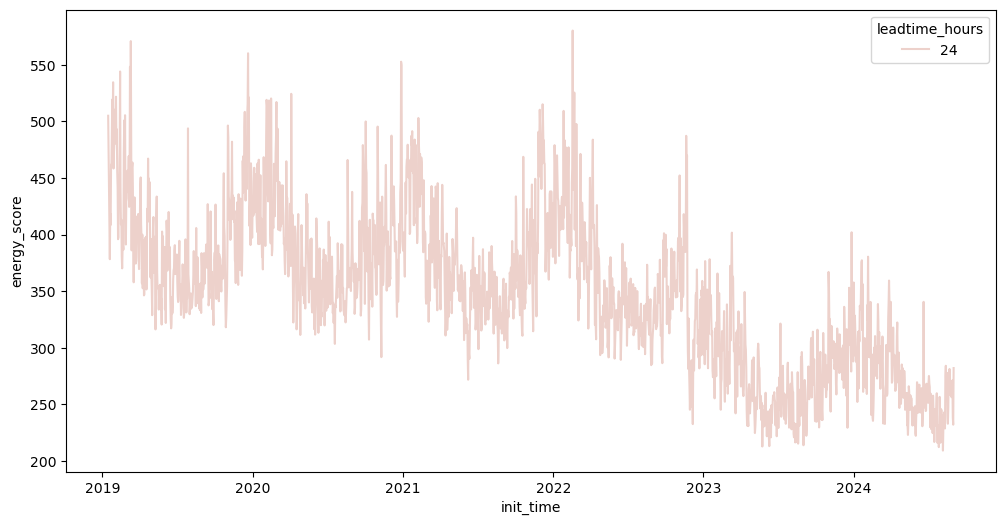

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=df.filter(pl.col("leadtime_hours") == 24),
    x="init_time",
    y="energy_score",
    hue="leadtime_hours",
    ax=ax,
)

In [7]:
grouped_df = df.group_by(pl.col("init_time").dt.year().alias("year"), pl.col("leadtime_hours")).agg(
    pl.col(pl.Float64).mean()
)

<Axes: xlabel='year', ylabel='energy_score'>

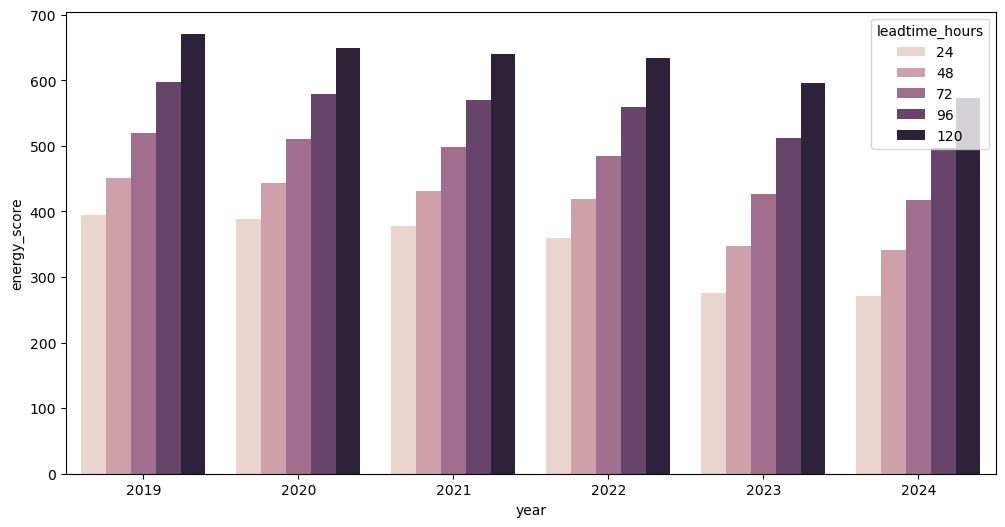

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=grouped_df, x="year", y="energy_score", hue="leadtime_hours", ax=ax)

<Axes: xlabel='year', ylabel='energy_score_VMAX_10M'>

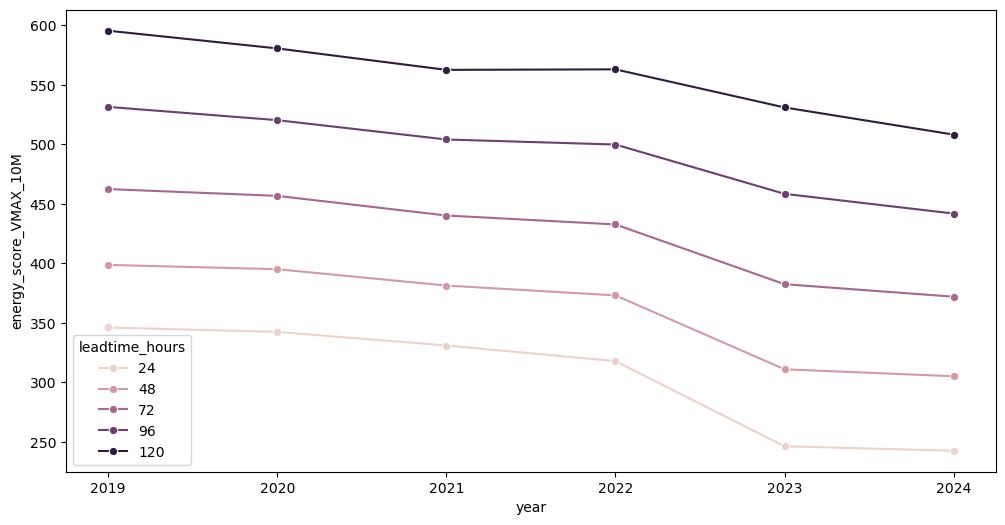

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=grouped_df, x="year", y="energy_score_VMAX_10M", hue="leadtime_hours", marker="o", ax=ax
)